# MH-Weed16: YOLO11 Object Detection, Agricultural Analytics, and Sliced Inference

This notebook provides an end-to-end pipeline for multiclass weed detection on the MH-Weed16 dataset using Ultralytics YOLO11.

### Pipeline Structure:
1. Environment Setup and Hardware Diagnostic
2. Zero-Duplication Dataset Partitioning and Directory Configuration
3. Exploratory Data Analysis (EDA) and Label Integrity Audit
4. Multi-Modal Feature Engineering and Spectral Vegetation Indices
5. Principal Component Analysis (PCA) and Dimensionality Reduction
6. Outlier Detection and Anomaly Auditing (Isolation Forest)
7. Bounding Box Anchor Geometry Analysis (K-Means)
8. Agricultural Image Contrast Enhancement (CLAHE and ExG)
9. Genetic Algorithm Hyperparameter Evolution (model.tune)
10. Hyperparameter Visual Analytics Suite
11. Resumable Model Training and Test Evaluation
12. Inference, SAHI Sliced Prediction, and Edge Export

## 1. Environment Setup and Hardware Diagnostic
Import required libraries, verify compute acceleration (Intel Arc Graphics via PyTorch XPU, CUDA, or CPU fallback), and establish reproducible random seeds.

In [1]:
import os
import sys
import time
import glob
import math
import random
import shutil
import pathlib
import subprocess
import concurrent.futures
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import yaml

import torch
import torchvision
import ultralytics
from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Seed initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT_DIR = pathlib.Path(".").resolve()

# Compute device detection
if hasattr(torch, 'xpu') and torch.xpu.is_available():
    device = 'xpu'
    device_name = torch.xpu.get_device_name(0)
elif torch.cuda.is_available():
    device = 'cuda'
    device_name = torch.cuda.get_device_name(0)
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
    device_name = 'Apple Silicon MPS'
else:
    device = 'cpu'
    device_name = 'CPU'

print("=" * 65)
print(f"Working Directory:   {ROOT_DIR}")
print(f"PyTorch Version:     {torch.__version__}")
print(f"Ultralytics Version: {ultralytics.__version__}")
print(f"Compute Device:      {device} ({device_name})")
print("=" * 65)

Working Directory:   D:\proj\MHWeed16\mhweedaiml
PyTorch Version:     2.14.1+xpu
Ultralytics Version: 8.4.150
Compute Device:      xpu (Intel(R) Arc(TM) Graphics)


## 2. Zero-Duplication Dataset Partitioning and Directory Configuration
Ultralytics requires dataset paths and configuration formatted in a YAML file.
To avoid copying 6,656 images (over 4 GB), we create directory junctions (`images` and `labels`) pointing directly to the raw dataset and partition the indices into `train.txt` (80%), `val.txt` (10%), and `test.txt` (10%).

In [2]:
RAW_IMAGES = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Clicks" / "intel Real Sense Depth_Clicks"
RAW_LABELS = ROOT_DIR / "MH-Weed16" / "Crop with Weeds" / "intel Real Sense Depth_Annotations" / "intel Real Sense Depth_Annotations" / "YOLO_darknet"

IMAGES_DIR = ROOT_DIR / "images"
LABELS_DIR = ROOT_DIR / "labels"
ANN_DIR = ROOT_DIR / "annotations"

# Create symbolic junctions if they do not exist
if not IMAGES_DIR.exists() and RAW_IMAGES.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{IMAGES_DIR}" "{RAW_IMAGES}"', shell=True, capture_output=True)
    else:
        IMAGES_DIR.symlink_to(RAW_IMAGES)

if not LABELS_DIR.exists() and RAW_LABELS.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{LABELS_DIR}" "{RAW_LABELS}"', shell=True, capture_output=True)
    else:
        LABELS_DIR.symlink_to(RAW_LABELS)

# Keep annotations alias synced
if not ANN_DIR.exists() and LABELS_DIR.exists():
    if os.name == 'nt':
        subprocess.run(f'cmd /c mklink /J "{ANN_DIR}" "{LABELS_DIR}"', shell=True, capture_output=True)
    else:
        ANN_DIR.symlink_to(LABELS_DIR)

raw_image_files = sorted([p for p in IMAGES_DIR.glob('*.*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
print(f"Raw images discovered: {len(raw_image_files):,}")

Raw images discovered: 6,656


In [3]:
# 80 / 10 / 10 Train / Val / Test Partitioning
shuffled_images = list(raw_image_files)
random.seed(SEED)
random.shuffle(shuffled_images)

n_total = len(shuffled_images)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_paths = [os.path.normpath(str(p)) for p in shuffled_images[:n_train]]
val_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train:n_train + n_val]]
test_paths = [os.path.normpath(str(p)) for p in shuffled_images[n_train + n_val:]]

def write_split_file(filepath, paths):
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write('\n'.join(paths) + '\n')

write_split_file(ROOT_DIR / "train.txt", train_paths)
write_split_file(ROOT_DIR / "val.txt", val_paths)
write_split_file(ROOT_DIR / "test.txt", test_paths)

print(f"Splits saved: Train={len(train_paths):,} | Val={len(val_paths):,} | Test={len(test_paths):,}")

# Botanical weed species definitions
CLASS_NAMES = {
    0: "kena",
    1: "lavhala",
    2: "lambs_quarters",
    3: "little_mallow",
    4: "moti_dudhi",
    5: "obscure_morning_glory",
    6: "asian_pigeonwings",
    7: "bilayat",
    8: "choti_dudhi",
    9: "digitaria",
    10: "gajar_gavat",
    11: "graceful_sandmat",
    12: "sicklepod",
    13: "harali",
    14: "dwarf_cassia"
}

yaml_content = {
    'path': str(ROOT_DIR).replace('\\', '/'),
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': CLASS_NAMES
}

yaml_file = ROOT_DIR / "mhweed16.yaml"
with open(yaml_file, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"Generated dataset YAML: {yaml_file}")

Splits saved: Train=5,324 | Val=665 | Test=667
Generated dataset YAML: D:\proj\MHWeed16\mhweedaiml\mhweed16.yaml


## 3. Exploratory Data Analysis and Label Integrity Audit
Audit normalized bounding box coordinates for out-of-bounds values, examine class balance across all 15 weed species, and visualize ground-truth annotations.

In [4]:
# Parse all annotations and check integrity
ann_files = sorted(list(LABELS_DIR.glob('*.txt')))
box_records = []
corrupt_files = []
out_of_bounds = 0

for ann_path in ann_files:
    try:
        with open(ann_path, 'r', encoding='utf-8') as f:
            lines = [l.strip().split() for l in f if l.strip()]
        for parts in lines:
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            if not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0 and 0.0 < bw <= 1.0 and 0.0 < bh <= 1.0):
                out_of_bounds += 1
            box_records.append({
                'image': ann_path.stem,
                'class_id': cls_id,
                'species': CLASS_NAMES.get(cls_id, f"weed_{cls_id}"),
                'xc': xc,
                'yc': yc,
                'width': bw,
                'height': bh,
                'area': bw * bh,
                'aspect_ratio': bw / max(bh, 1e-6)
            })
    except Exception as e:
        corrupt_files.append((ann_path.name, str(e)))

df_boxes = pd.DataFrame(box_records)
print(f"Total Annotation Files: {len(ann_files):,}")
print(f"Total Bounding Boxes:   {len(df_boxes):,}")
print(f"Corrupt Files:          {len(corrupt_files)}")
print(f"Out of Bounds Boxes:    {out_of_bounds}")

Total Annotation Files: 6,656
Total Bounding Boxes:   62,052
Corrupt Files:          0
Out of Bounds Boxes:    12


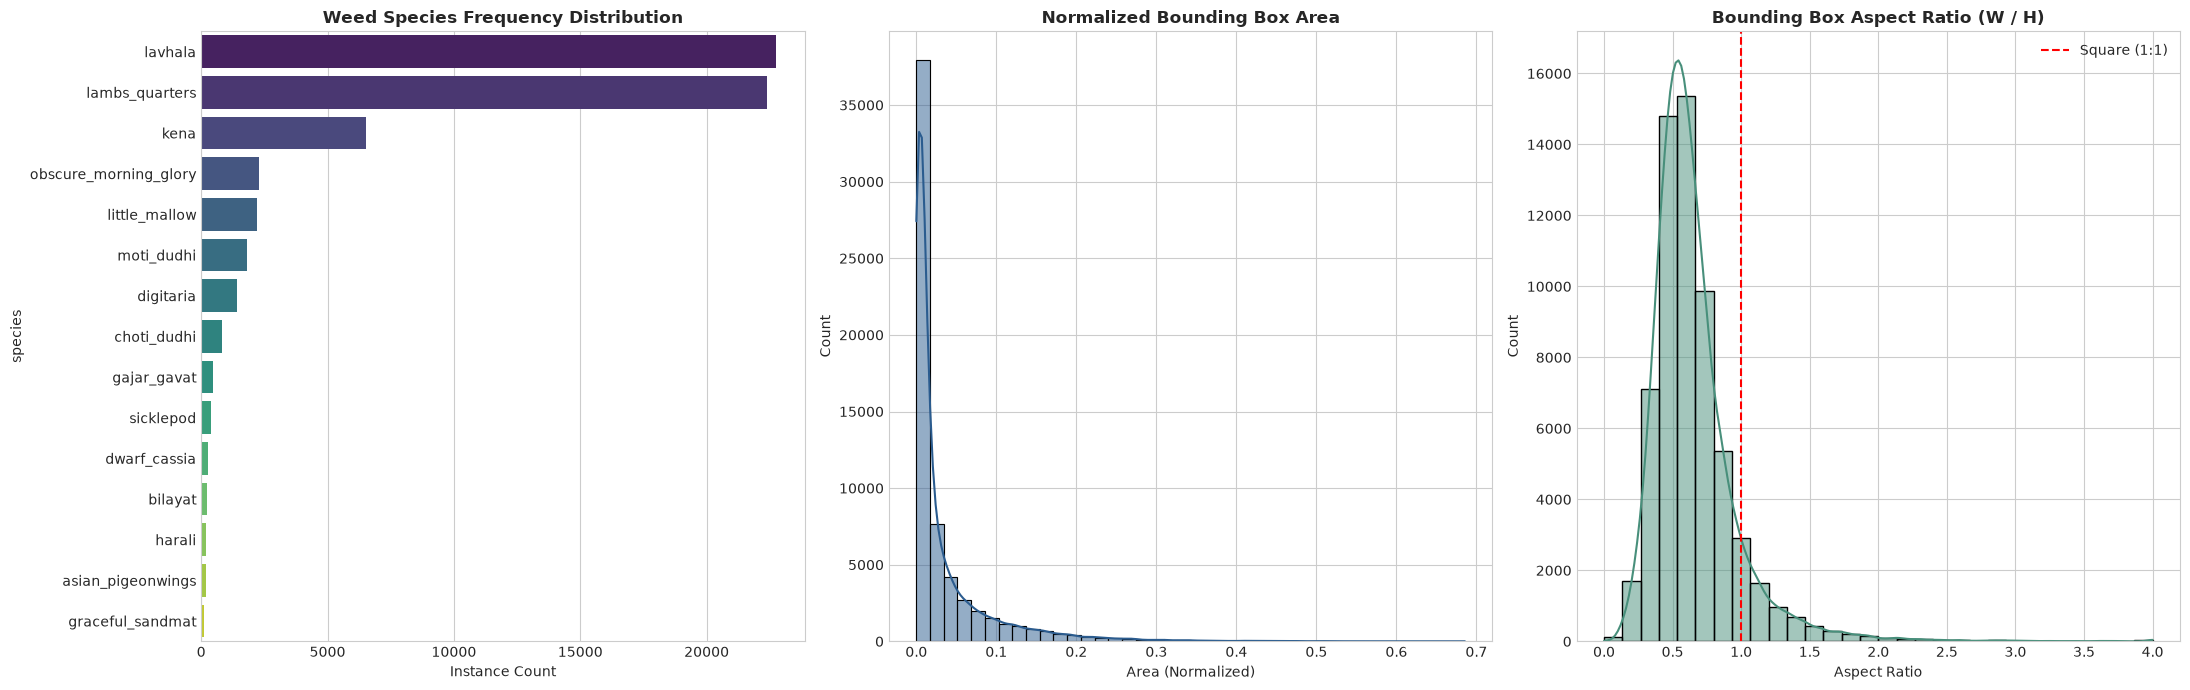

In [5]:
# Plot class distribution and bounding box geometry
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Class distribution (Fixed FutureWarning by setting hue=y and legend=False)
species_counts = df_boxes['species'].value_counts()
sns.barplot(
    x=species_counts.values, 
    y=species_counts.index, 
    hue=species_counts.index, 
    legend=False, 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title("Weed Species Frequency Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Instance Count")

# 2. Bounding box area distribution
sns.histplot(df_boxes['area'], bins=40, kde=True, ax=axes[1], color='#2b5c8f')
axes[1].set_title("Normalized Bounding Box Area", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Area (Normalized)")

# 3. Aspect ratio distribution (Replaced boxplot with violinplot + inner box for better distribution detail)
# 3. Aspect ratio distribution (KDE Density Plot with Square Reference Line)
sns.histplot(df_boxes['aspect_ratio'].clip(0, 4), kde=True, ax=axes[2], color='#488f7b', bins=30)
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Square (1:1)')
axes[2].set_title("Bounding Box Aspect Ratio (W / H)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Aspect Ratio")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

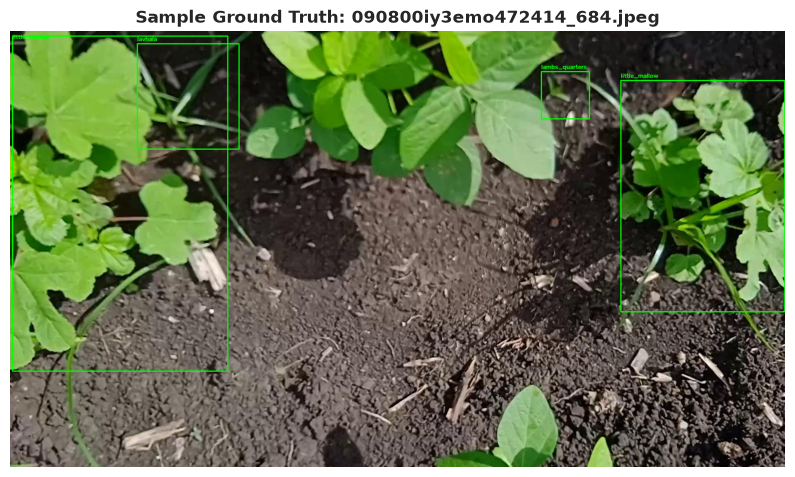

In [6]:
def show_sample_ground_truth(img_path, ann_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return
    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = int((xc - bw / 2.0) * w_img)
                y1 = int((yc - bh / 2.0) * h_img)
                x2 = int((xc + bw / 2.0) * w_img)
                y2 = int((yc + bh / 2.0) * h_img)
                species = CLASS_NAMES.get(cls_id, str(cls_id))
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_rgb, species, (x1, max(20, y1 - 6)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f"Sample Ground Truth: {img_path.name}", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

sample_img = raw_image_files[0]
sample_ann = LABELS_DIR / f"{sample_img.stem}.txt"
show_sample_ground_truth(sample_img, sample_ann)

## 4. Multi-Modal Feature Engineering and Spectral Vegetation Indices
Extract morphological dimensions, RGB/HSV color statistics, and agronomic vegetation indices across weed instances:
- Excess Green Index ($ExG = 2G - R - B$)
- Excess Red Index ($ExR = 1.4R - G$)
- Normalized Difference Index ($NDI = (G - R) / (G + R)$)
- Texture contrast via Laplacian variance

In [7]:
def extract_instance_features(img_path):
    ann_path = LABELS_DIR / f"{img_path.stem}.txt"
    if not ann_path.exists():
        return []
    
    img = cv2.imread(str(img_path))
    if img is None:
        return []
    
    h_img, w_img = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    with open(ann_path, 'r', encoding='utf-8') as f:
        lines = [line.strip().split() for line in f if line.strip()]
    
    n_boxes = len(lines)
    records = []
    
    for parts in lines:
        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])
        
        x1 = max(0, int((xc - bw / 2.0) * w_img))
        y1 = max(0, int((yc - bh / 2.0) * h_img))
        x2 = min(w_img, int((xc + bw / 2.0) * w_img))
        y2 = min(h_img, int((yc + bh / 2.0) * h_img))
        
        patch_rgb = img_rgb[y1:y2, x1:x2]
        if patch_rgb.size < 12:
            continue
        
        patch_hsv = img_hsv[y1:y2, x1:x2]
        patch_gray = img_gray[y1:y2, x1:x2]
        
        rf = patch_rgb[:, :, 0].astype(np.float32) / 255.0
        gf = patch_rgb[:, :, 1].astype(np.float32) / 255.0
        bf = patch_rgb[:, :, 2].astype(np.float32) / 255.0
        
        exg = 2.0 * gf - rf - bf
        exr = 1.4 * rf - gf
        denom = gf + rf + 1e-6
        ndi = (gf - rf) / denom
        
        lap_var = float(cv2.Laplacian(patch_gray, cv2.CV_64F).var()) if patch_gray.size >= 16 else 0.0
        
        records.append({
            'image_name': img_path.name,
            'class_id': cls_id,
            'species': CLASS_NAMES.get(cls_id, str(cls_id)),
            'xc': xc,
            'yc': yc,
            'width': bw,
            'height': bh,
            'aspect_ratio': bw / max(bh, 1e-6),
            'area': bw * bh,
            'perimeter': 2.0 * (bw + bh),
            'center_dist': np.sqrt((xc - 0.5)**2 + (yc - 0.5)**2),
            'boxes_in_frame': n_boxes,
            'r_mean': float(np.mean(rf)),
            'g_mean': float(np.mean(gf)),
            'b_mean': float(np.mean(bf)),
            'hue_mean': float(np.mean(patch_hsv[:, :, 0])),
            'sat_mean': float(np.mean(patch_hsv[:, :, 1])),
            'val_mean': float(np.mean(patch_hsv[:, :, 2])),
            'exg_mean': float(np.mean(exg)),
            'exr_mean': float(np.mean(exr)),
            'ndi_mean': float(np.mean(ndi)),
            'contrast_std': float(np.std(patch_gray)),
            'laplacian_var': lap_var
        })
        
    return records

sample_feature_images = raw_image_files[:min(1000, len(raw_image_files))]
print(f"Extracting multi-modal features across sample of {len(sample_feature_images):,} raw frames...")
t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    extracted_batches = list(executor.map(extract_instance_features, sample_feature_images))

feature_list = [r for batch in extracted_batches for r in batch]
df_features = pd.DataFrame(feature_list)
t1 = time.time()

print(f"Extraction complete in {t1 - t0:.2f}s: Extracted {len(df_features):,} weed instances.")
df_features.head()

Extracting multi-modal features across sample of 1,000 raw frames...
Extraction complete in 17.01s: Extracted 7,576 weed instances.


,image_name,class_id,species,xc,yc,width,height,aspect_ratio,area,perimeter,...,g_mean,b_mean,hue_mean,sat_mean,val_mean,exg_mean,exr_mean,ndi_mean,contrast_std,laplacian_var
0,090800iy3emo472414_684.jpeg,3,little_mallow,0.893750,0.378704,0.211458,0.531481,0.397866,0.112386,1.485880,...,0.415917,0.230628,41.825514,127.665042,107.498169,0.287341,0.023494,0.176177,60.557920,147.139817
1,090800iy3emo472414_684.jpeg,3,little_mallow,0.142187,0.395370,0.277083,0.768519,0.360542,0.212944,2.091204,...,0.496012,0.249384,36.404241,126.021992,128.776130,0.350125,0.053507,0.119047,53.225372,65.762377
2,090800iy3emo472414_684.jpeg,1,lavhala,0.229687,0.150000,0.131250,0.242593,0.541031,0.031840,0.747685,...,0.246645,0.144571,37.870355,104.473393,63.753391,0.149011,0.032946,0.096716,48.249966,46.202649
3,090800iy3emo472414_684.jpeg,2,lambs_quarters,0.716406,0.146759,0.061979,0.108333,0.572115,0.006714,0.340625,...,0.286917,0.222887,27.645120,72.371472,76.179272,0.071275,0.104624,0.006381,40.485350,77.894911
4,090805j6869f452411_137.jpeg,2,lambs_quarters,0.150781,0.609259,0.073438,0.107407,0.683728,0.007888,0.361690,...,0.381852,0.279632,38.699743,70.667706,102.747738,0.114123,0.136078,-0.004547,37.766097,82.787602


## 5. Principal Component Analysis (PCA) and Dimensionality Reduction
Standardize the multi-modal feature matrix and project high-dimensional descriptors into 2D latent space to assess weed class separability.

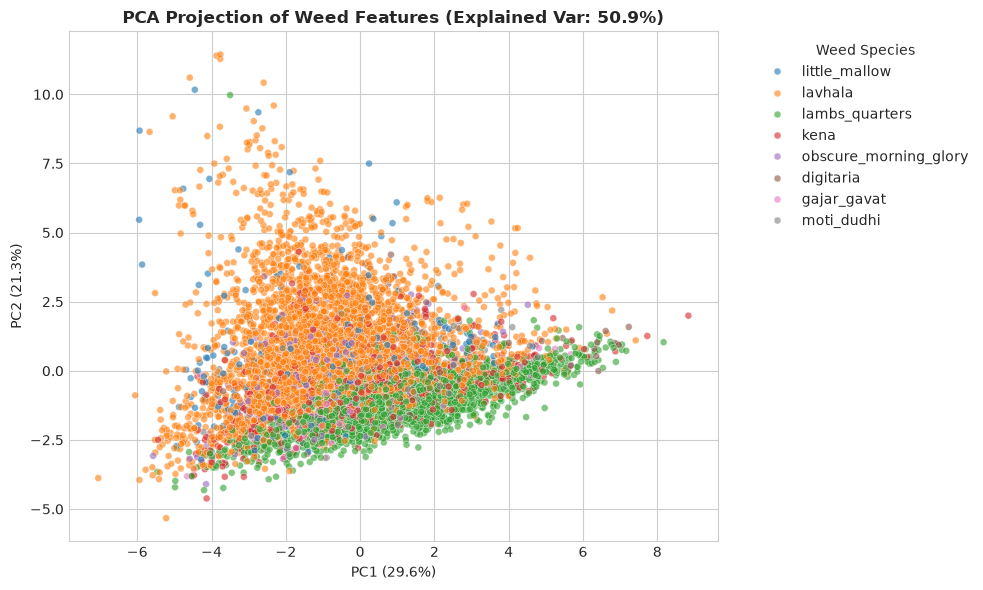

In [8]:
feature_cols = [
    'width', 'height', 'aspect_ratio', 'area', 'perimeter', 'center_dist',
    'r_mean', 'g_mean', 'b_mean', 'hue_mean', 'sat_mean', 'val_mean',
    'exg_mean', 'exr_mean', 'ndi_mean', 'contrast_std', 'laplacian_var'
]

X = df_features[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
df_features['pca_1'] = X_pca[:, 0]
df_features['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
top_species = df_features['species'].value_counts().head(8).index
sns.scatterplot(
    data=df_features[df_features['species'].isin(top_species)],
    x='pca_1',
    y='pca_2',
    hue='species',
    alpha=0.6,
    s=25
)
plt.title(f"PCA Projection of Weed Features (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Weed Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Outlier Detection and Anomaly Auditing
Utilize an Isolation Forest to identify anomalous or corrupt bounding box annotations (extreme aspect ratios, speckle noise, mislabeled large boxes).

In [9]:
iso_forest = IsolationForest(contamination=0.01, random_state=SEED, n_jobs=-1)
df_features['anomaly_score'] = -iso_forest.fit(X_scaled).score_samples(X_scaled)
df_features['outlier_iso'] = iso_forest.predict(X_scaled) == -1

print("=" * 60)
print("DATASET OUTLIER AUDIT SUMMARY")
print(f"Total instances audited:        {len(df_features):,}")
print(f"Isolation Forest anomalies:     {df_features['outlier_iso'].sum():,}")
print("=" * 60)

# Top anomalies inspection
top_anomalies = df_features.sort_values(by='anomaly_score', ascending=False).head(5)
top_anomalies[['image_name', 'species', 'width', 'height', 'area', 'anomaly_score']]

DATASET OUTLIER AUDIT SUMMARY
Total instances audited:        7,576
Isolation Forest anomalies:     76


,image_name,species,width,height,area,anomaly_score
6433,11080t42i64h232555_162.jpeg,little_mallow,0.597396,0.799074,0.477364,0.670737
6773,110810tsq042222554_747.jpeg,little_mallow,0.664583,0.507407,0.337215,0.647536
4242,1008nszt7j09182402_152.jpeg,lavhala,0.012500,0.026852,0.000336,0.646957
4425,1008pu29wm35132432_63..jpeg,little_mallow,0.543750,0.925926,0.503472,0.639758
4426,1008pu29wm35132432_63..jpeg,little_mallow,0.420833,0.827778,0.348356,0.630036


## 7. Bounding Box Anchor Geometry Analysis (K-Means)
Cluster normalized bounding box dimensions using K-Means to identify dominant spatial aspect ratios and scales in the MH-Weed16 dataset.

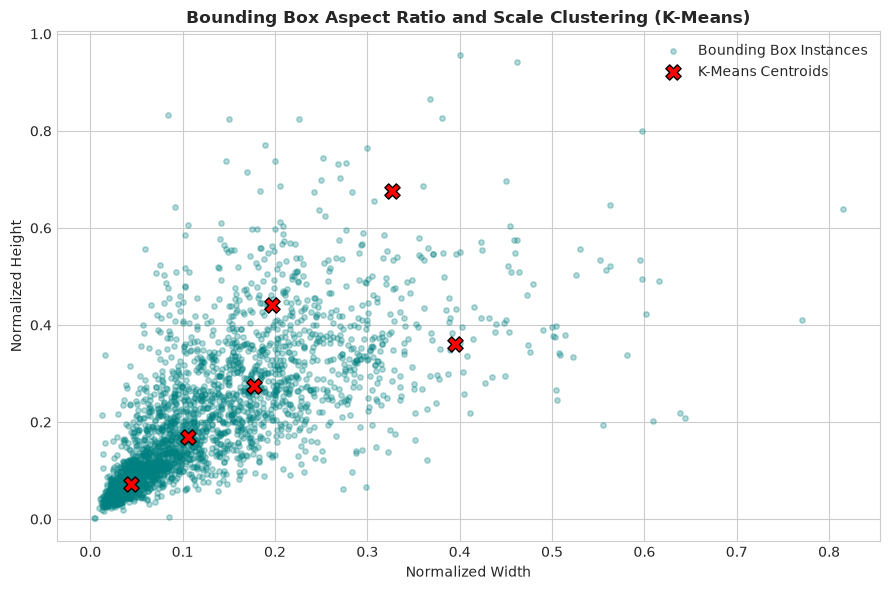

In [10]:
wh_data = df_features[['width', 'height']].values
k_clusters = 6
kmeans = KMeans(n_clusters=k_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(wh_data)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(9, 6))
plt.scatter(
    df_features['width'].sample(min(3000, len(df_features)), random_state=SEED),
    df_features['height'].sample(min(3000, len(df_features)), random_state=SEED),
    alpha=0.3,
    c='teal',
    s=15,
    label='Bounding Box Instances'
)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=120,
    edgecolors='black',
    label='K-Means Centroids'
)
plt.title("Bounding Box Aspect Ratio and Scale Clustering (K-Means)", fontsize=12, fontweight='bold')
plt.xlabel("Normalized Width")
plt.ylabel("Normalized Height")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Agricultural Image Contrast Enhancement (CLAHE and ExG)
Demonstrate field-level image enhancements for difficult lighting conditions using CLAHE (Contrast Limited Adaptive Histogram Equalization) and the Excess Green index.

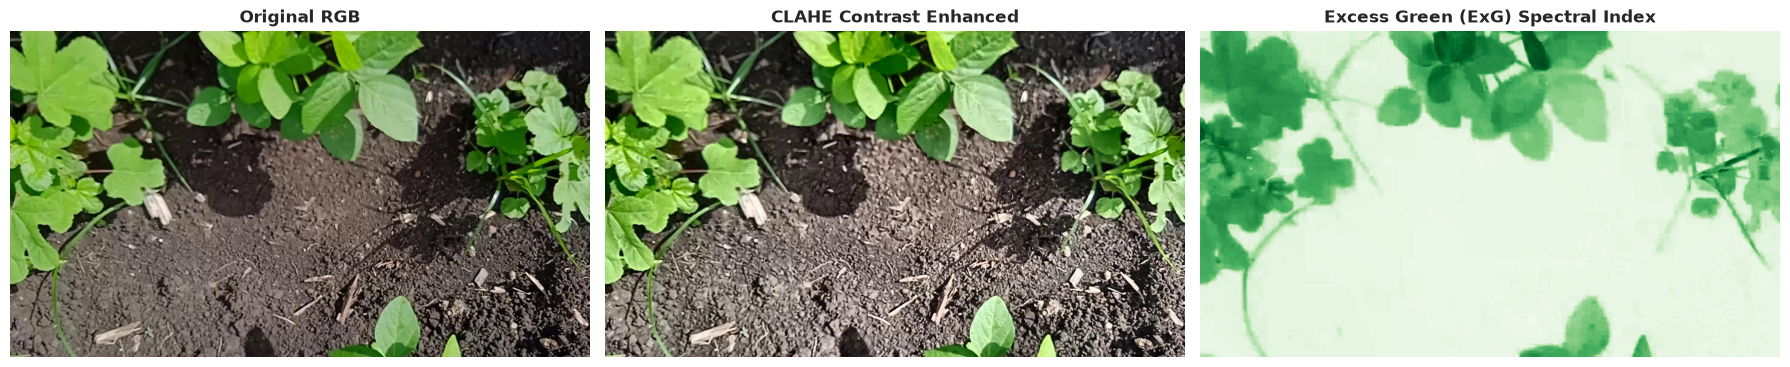

In [11]:
def apply_clahe(img_rgb, clip_limit=2.0):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)

def compute_exg(img_rgb):
    rf = img_rgb[:, :, 0].astype(np.float32) / 255.0
    gf = img_rgb[:, :, 1].astype(np.float32) / 255.0
    bf = img_rgb[:, :, 2].astype(np.float32) / 255.0
    exg = 2.0 * gf - rf - bf
    return np.clip((exg + 1.0) / 2.0 * 255.0, 0, 255).astype(np.uint8)

sample_raw = cv2.imread(str(raw_image_files[0]))
sample_rgb = cv2.cvtColor(sample_raw, cv2.COLOR_BGR2RGB)
sample_clahe = apply_clahe(sample_rgb)
sample_exg = compute_exg(sample_rgb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(sample_rgb)
axes[0].set_title("Original RGB", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_clahe)
axes[1].set_title("CLAHE Contrast Enhanced", fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(sample_exg, cmap='Greens')
axes[2].set_title("Excess Green (ExG) Spectral Index", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 9. Genetic Algorithm Hyperparameter Evolution (model.tune)
Ultralytics supports native Genetic Algorithm hyperparameter evolution.
By default, `RUN_TUNE = False` allows the notebook to run immediately using either previously saved optimal hyperparameters or robust defaults.

In [ ]:
RUN_TUNE = True         # Set to True to execute hyperparameter evolution
TUNE_ITERATIONS = 20     # Number of evolution generations
TUNE_EPOCHS = 30         # Epochs per trial
BATCH_SIZE = -1           # Batch size for compute device
IMG_SIZE = 640           # High-resolution input canvas

tune_results_file = ROOT_DIR / "tune_results.csv"
best_hyp_file = ROOT_DIR / "best_hyperparameters.yaml"

if RUN_TUNE:
    print("=" * 65)
    print("Starting Genetic Algorithm Hyperparameter Evolution via model.tune()...")
    tune_model = YOLO("yolo11n.pt")
    tune_model.tune(
        data="mhweed16.yaml",
        epochs=TUNE_EPOCHS,
        iterations=TUNE_ITERATIONS,
        optimizer="AdamW",
        plots=False,
        save=False,
        val=True,
        device=device,
        batch=BATCH_SIZE,
        imgsz=IMG_SIZE
    )
else:
    print("RUN_TUNE is set to False: Skipping hyperparameter evolution.")
    if best_hyp_file.exists():
        print(f"Discovered existing evolved hyperparameters: {best_hyp_file}")
    else:
        print("Using robust agricultural default hyperparameters for final training.")

Starting Genetic Algorithm Hyperparameter Evolution via model.tune()...
Tuner: Initialized Tuner instance with 'tune_dir=D:\proj\MHWeed16\mhweedaiml\runs\detect\tune-3'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/20 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}

MultiTrainer 1/1: fine-tuning on mhweed16.yaml


## 10. Hyperparameter Visual Analytics Suite
Inspect evolution trials from `tune_results.csv` (if present) via fitness progression and hyperparameter correlations.

In [ ]:
if tune_results_file.exists():
    df_tune = pd.read_csv(tune_results_file)
    print(f"Loaded {len(df_tune)} completed evolution trial(s) from {tune_results_file.name}:")
    
    if 'generation' not in df_tune.columns:
        df_tune['generation'] = range(1, len(df_tune) + 1)
    
    fitness_col = 'fitness' if 'fitness' in df_tune.columns else ('metrics/mAP50-95(B)' if 'metrics/mAP50-95(B)' in df_tune.columns else None)
    
    if fitness_col:
        plt.figure(figsize=(10, 4))
        plt.plot(df_tune['generation'], df_tune[fitness_col], marker='o', color='#2b5c8f', linewidth=2)
        plt.title("Hyperparameter Evolution Fitness Progression", fontsize=12, fontweight='bold')
        plt.xlabel("Generation Trial")
        plt.ylabel("Fitness Score")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("Note: tune_results.csv not found. Execute Section 9 with RUN_TUNE = True to generate evolution analytics.")

## 11. Resumable Final Model Training and Evaluation
Train YOLO11 Nano (`yolo11n.pt`) with optimal hyperparameters.
The training block detects existing checkpoints and automatically resumes (`resume=True`) if `last.pt` is found.

In [ ]:
RUN_TRAIN = True
EPOCHS = 50
BATCH_SIZE = 8
IMG_SIZE = 640
RUN_NAME = "mhweed16_yolo11n_final"

run_dir = ROOT_DIR / "runs" / "detect" / RUN_NAME
weights_dir = run_dir / "weights"
last_weights = weights_dir / "last.pt"
best_weights = weights_dir / "best.pt"

if RUN_TRAIN:
    print("=" * 65)
    print(f"Final YOLO11n Training: {RUN_NAME}")
    print(f"Device:     {device} ({device_name})")
    print(f"Epochs:     {EPOCHS}")
    print(f"Batch:      {BATCH_SIZE}")
    print(f"Image Size: {IMG_SIZE}")
    print("=" * 65)
    
    if last_weights.exists():
        print(f"Resuming training from checkpoint: {last_weights}")
        model = YOLO(str(last_weights))
        train_args = {'resume': True}
    else:
        print("Initializing fresh YOLO11 Nano architecture (yolo11n.pt)...")
        model = YOLO("yolo11n.pt")
        train_args = {
            'data': "mhweed16.yaml",
            'epochs': EPOCHS,
            'batch': BATCH_SIZE,
            'imgsz': IMG_SIZE,
            'device': device,
            'workers': 4,
            'name': RUN_NAME,
            'project': "runs/detect",
            'exist_ok': True,
            'pretrained': True,
            'optimizer': "AdamW",
            'patience': 15,
            'save': True
        }
        if best_hyp_file.exists():
            with open(best_hyp_file, 'r', encoding='utf-8') as f:
                best_hyp = yaml.safe_load(f)
            train_args.update(best_hyp)
            print("Loaded evolved hyperparameters into training configuration.")
            
    results = model.train(**train_args)
else:
    print("RUN_TRAIN is set to False: Skipping model training.")

In [ ]:
# Evaluation on held-out test split
eval_weights = best_weights if best_weights.exists() else (last_weights if last_weights.exists() else pathlib.Path("yolo11n.pt"))
print(f"Evaluating checkpoint: {eval_weights}")

eval_model = YOLO(str(eval_weights))
metrics = eval_model.val(
    data="mhweed16.yaml",
    split="test",
    device=device,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE
)

print("=" * 60)
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print("=" * 60)

## 12. Inference, SAHI Sliced Prediction, and Edge Export
Demonstrate standard full-frame YOLO prediction against ground truth annotations, perform fine-grained Slicing Aided Hyper Inference (SAHI) on full 1080p images, and export the model to ONNX and OpenVINO.

In [ ]:
# Standard YOLO inference comparison
with open("test.txt", 'r', encoding='utf-8') as f:
    test_image_paths = [pathlib.Path(line.strip()) for line in f if line.strip()]

random.seed(123)
selected_test = random.sample(test_image_paths, min(3, len(test_image_paths)))

for test_path in selected_test:
    ann_path = LABELS_DIR / f"{test_path.stem}.txt"
    img = cv2.imread(str(test_path))
    gt_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = gt_img.shape[:2]
    
    # Draw ground truth
    if ann_path.exists():
        with open(ann_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = int((xc - bw / 2.0) * w_img)
                    y1 = int((yc - bh / 2.0) * h_img)
                    x2 = int((xc + bw / 2.0) * w_img)
                    y2 = int((yc + bh / 2.0) * h_img)
                    cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(gt_img, CLASS_NAMES.get(cls_id, str(cls_id)), (x1, max(20, y1 - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Model prediction
    pred_res = eval_model.predict(source=str(test_path), imgsz=IMG_SIZE, conf=0.25, device=device, verbose=False)
    pred_img = pred_res[0].plot()[:, :, ::-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(gt_img)
    axes[0].set_title(f"Ground Truth: {test_path.name}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(pred_img)
    axes[1].set_title(f"YOLO11 Prediction: {test_path.name}", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Slicing Aided Hyper Inference (SAHI)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=str(eval_weights),
    confidence_threshold=0.25,
    device=device if device != 'xpu' else 'cpu'
)

fig, axes = plt.subplots(len(selected_test), 2, figsize=(16, 6 * len(selected_test)))
if len(selected_test) == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, test_p in enumerate(selected_test):
    raw = cv2.imread(str(test_p))
    gt_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(raw.copy(), cv2.COLOR_BGR2RGB)
    h, w = gt_img.shape[:2]
    
    ann_p = LABELS_DIR / f"{test_p.stem}.txt"
    if ann_p.exists():
        with open(ann_p, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(gt_img, CLASS_NAMES.get(cid, str(cid)), (x1, max(20, y1 - 5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    sahi_result = get_sliced_prediction(
        str(test_p),
        sahi_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )
    
    for obj in sahi_result.object_prediction_list:
        bbox = obj.bbox.to_xyxy()
        x1, y1, x2, y2 = map(int, bbox)
        cat_name = obj.category.name
        score = obj.score.value
        cv2.rectangle(pred_img, (x1, y1), (x2, y2), (255, 50, 50), 2)
        cv2.putText(pred_img, f"{cat_name} {score:.2f}", (x1, max(20, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 50, 50), 2)

    axes[idx, 0].imshow(gt_img)
    axes[idx, 0].set_title(f"Ground Truth ({test_p.name})", fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(pred_img)
    axes[idx, 1].set_title(f"SAHI 640x640 Sliced Inference ({len(sahi_result.object_prediction_list)} weeds)", fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Export model for edge deployment
print("Exporting model for edge deployment...")

# 1. Export to ONNX format
try:
    onnx_path = eval_model.export(format="onnx", dynamic=True)
    print(f"Successfully exported ONNX model: {onnx_path}")
except Exception as e:
    print(f"ONNX export skipped: {e}")

# 2. Export to OpenVINO format (optimized for Intel Arc GPU / CPU)
try:
    openvino_path = eval_model.export(format="openvino", half=True)
    print(f"Successfully exported OpenVINO model: {openvino_path}")
except Exception as e:
    print(f"OpenVINO export skipped: {e}")